In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Attention, GlobalAveragePooling1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [2]:
base_path = "/content/drive/MyDrive/dataset"

all_sequences = []
all_labels = []

TIME_STEPS = 100
STEP = 20  # overlap

def find_column(cols, keywords):
    for col in cols:
        for key in keywords:
            if key in col.lower():
                return col
    return None

for rating in range(1, 6):
    folder_path = os.path.join(base_path, f"{rating}_star")

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        try:
            if file.endswith(".csv"):
                df = pd.read_csv(file_path)
            elif file.endswith(".xlsx"):
                df = pd.read_excel(file_path)
            else:
                continue

            df.columns = df.columns.str.strip()
            cols = df.columns.tolist()

            ax = find_column(cols, ['x_acc','acc_x'])
            ay = find_column(cols, ['y_acc','acc_y'])
            az = find_column(cols, ['z_acc','acc_z'])
            gx = find_column(cols, ['x_gyro','gyro_x'])
            gy = find_column(cols, ['y_gyro','gyro_y'])
            gz = find_column(cols, ['z_gyro','gyro_z'])

            if None in [ax, ay, az, gx, gy, gz]:
                continue

            df = df[[ax, ay, az, gx, gy, gz]]
            df.columns = ['ax','ay','az','gx','gy','gz']

            # remove zero rows
            df = df[
                ~(
                    (df[['ax','ay','az']] == 0).all(axis=1) |
                    (df[['gx','gy','gz']] == 0).all(axis=1)
                 )
            ]

            # smoothing
            df = df.rolling(window=3).mean().dropna()

            # features
            df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
            df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

            df['jerk'] = np.sqrt(
                np.diff(df['ax'], prepend=df['ax'].iloc[0])**2 +
                np.diff(df['ay'], prepend=df['ay'].iloc[0])**2 +
                np.diff(df['az'], prepend=df['az'].iloc[0])**2
            )

            df['acc_var'] = df[['ax','ay','az']].rolling(5).var().mean(axis=1)
            df['gyro_var'] = df[['gx','gy','gz']].rolling(5).var().mean(axis=1)

            df = df.dropna()

            data = df.values

            # create sequences
            for i in range(0, len(data) - TIME_STEPS, STEP):
                seq = data[i:i+TIME_STEPS]
                all_sequences.append(seq)
                all_labels.append(rating)

        except Exception as e:
            print("Error:", file, e)

X = np.array(all_sequences)
y = np.array(all_labels)

print("Shape:", X.shape)

Shape: (136693, 100, 11)


In [3]:
nsamples, timesteps, features = X.shape

scaler = StandardScaler()

X = X.reshape(-1, features)
X = scaler.fit_transform(X)
X = X.reshape(nsamples, timesteps, features)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = to_categorical(y_train - 1, 5)
y_test = to_categorical(y_test - 1, 5)

In [5]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.1063332119299099), 1: np.float64(1.2037072912997535), 2: np.float64(0.837451370807168), 3: np.float64(0.7590681919147045), 4: np.float64(1.3265369498762676)}


In [6]:
from tensorflow.keras.layers import GRU

In [7]:
input_layer = Input(shape=(TIME_STEPS, X.shape[2]))

x = Bidirectional(GRU(128, return_sequences=True))(input_layer)
x = Dropout(0.3)(x)

x = Bidirectional(GRU(64, return_sequences=True))(x)

x = Attention()([x, x])

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 11)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 100, 256)  │    108,288 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 100, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 100, 128)  │    123,648 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 100, 128)  │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        325 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 240,517 (939.52 KB)

 Trainable params: 240,517 (939.52 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(patience=4, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights
)

Epoch 1/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 85s 23ms/step - accuracy: 0.6289 - loss: 0.8817 - val_accuracy: 0.7685 - val_loss: 0.5812 - learning_rate: 0.0010
Epoch 2/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 78s 23ms/step - accuracy: 0.7636 - loss: 0.5683 - val_accuracy: 0.7993 - val_loss: 0.4818 - learning_rate: 0.0010
Epoch 3/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 80s 23ms/step - accuracy: 0.7909 - loss: 0.5045 - val_accuracy: 0.8310 - val_loss: 0.4223 - learning_rate: 0.0010
Epoch 4/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 80s 23ms/step - accuracy: 0.8255 - loss: 0.4246 - val_accuracy: 0.8415 - val_loss: 0.3875 - learning_rate: 0.0010
Epoch 5/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 79s 23ms/step - accuracy: 0.8424 - loss: 0.3773 - val_accuracy: 0.8421 - val_loss: 0.3813 - learning_rate: 0.0010
Epoch 6/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 80s 23ms/step - accuracy: 0.8546 - loss: 0.3470 - val_accuracy: 0.8651 - val_loss: 0.3235 - learning_rate: 0.0010
Epoch 7/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 78s 23ms/step - accura

In [9]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8983 - loss: 0.2418
Accuracy: 0.8982771635055542


In [10]:
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1) + 1

def driving_score(p):
    return p * 20   # 1→20, 5→100

scores = [driving_score(p) for p in pred_classes]

print(scores[:10])

855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
[np.int64(80), np.int64(60), np.int64(100), np.int64(80), np.int64(100), np.int64(60), np.int64(20), np.int64(80), np.int64(80), np.int64(20)]


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

true = np.argmax(y_test, axis=1) + 1

print(confusion_matrix(true, pred_classes))
print(classification_report(true, pred_classes))

[[4592   20   10   35  279]
 [ 156 4412   29   25  110]
 [ 299   29 5754  113  244]
 [ 474   32  210 6188  323]
 [ 308    6   10   69 3612]]
              precision    recall  f1-score   support

           1       0.79      0.93      0.85      4936
           2       0.98      0.93      0.96      4732
           3       0.96      0.89      0.92      6439
           4       0.96      0.86      0.91      7227
           5       0.79      0.90      0.84      4005

    accuracy                           0.90     27339
   macro avg       0.90      0.90      0.90     27339
weighted avg       0.91      0.90      0.90     27339



In [12]:
def driver_type(label):
    mapping = {
        1: "Very Rash",
        2: "Rash",
        3: "Balanced",
        4: "Safe",
        5: "Very Safe"
    }
    return mapping[label]

In [13]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1) + 1
true_classes = np.argmax(y_test, axis=1) + 1

855/855 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


In [14]:
for i in range(10):
    print(f"Predicted: {driver_type(pred_classes[i])} | Actual: {driver_type(true_classes[i])}")

Predicted: Safe | Actual: Safe
Predicted: Balanced | Actual: Balanced
Predicted: Very Safe | Actual: Very Safe
Predicted: Safe | Actual: Safe
Predicted: Very Safe | Actual: Very Safe
Predicted: Balanced | Actual: Balanced
Predicted: Very Rash | Actual: Very Rash
Predicted: Safe | Actual: Safe
Predicted: Safe | Actual: Safe
Predicted: Very Rash | Actual: Very Rash


In [15]:
def driving_score(label):
    return label * 20

In [16]:
def evaluate_driver(sequence):
    seq = sequence.reshape(1, sequence.shape[0], sequence.shape[1])

    pred = model.predict(seq)

    label = np.argmax(pred) + 1
    confidence = np.max(pred)

    return {
        "Driver Type": driver_type(label),
        "Rating (1-5)": label,
        "Score (0-100)": driving_score(label),
        "Confidence": float(confidence)*100
    }

In [17]:
result = evaluate_driver(X_test[0])
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
{'Driver Type': 'Safe', 'Rating (1-5)': np.int64(4), 'Score (0-100)': np.int64(80), 'Confidence': 100.0}


In [18]:
def explain_driver(label):
    explanations = {
        1: "Frequent sudden acceleration, harsh braking, unstable motion",
        2: "Occasional aggressive turns and speed variations",
        3: "Moderate driving with some inconsistencies",
        4: "Smooth acceleration and controlled turns",
        5: "Very stable, smooth and controlled driving behavior"
    }
    return explanations[label]

In [19]:
def full_driver_report(sequence):
    seq = sequence.reshape(1, sequence.shape[0], sequence.shape[1])

    pred = model.predict(seq)

    label = np.argmax(pred) + 1
    confidence = np.max(pred)

    return {
        "Driver Type": driver_type(label),
        "Score": driving_score(label),
        "Confidence": float(confidence),
        "Behavior": explain_driver(label)
    }

In [20]:
results = []

for i in range(len(X_test)):
    label = pred_classes[i]

    results.append({
        "Type": driver_type(label),
        "Score": driving_score(label)
    })

import pandas as pd
df_results = pd.DataFrame(results)

print(df_results.head())

        Type  Score
0       Safe     80
1   Balanced     60
2  Very Safe    100
3       Safe     80
4  Very Safe    100


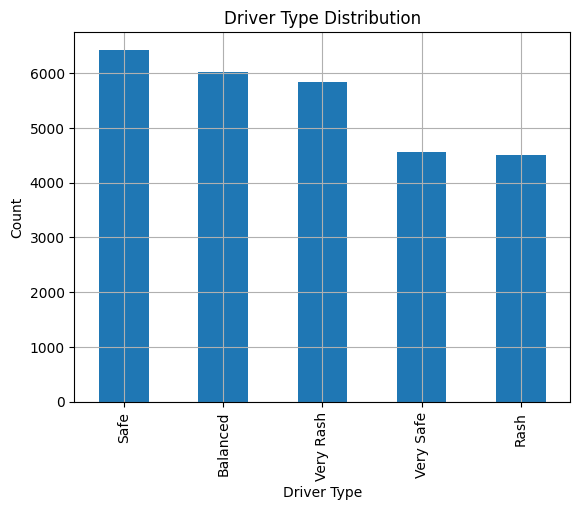

In [21]:
import matplotlib.pyplot as plt

df_results['Type'].value_counts().plot(kind='bar')

plt.title("Driver Type Distribution")
plt.xlabel("Driver Type")
plt.ylabel("Count")
plt.grid()

plt.show()

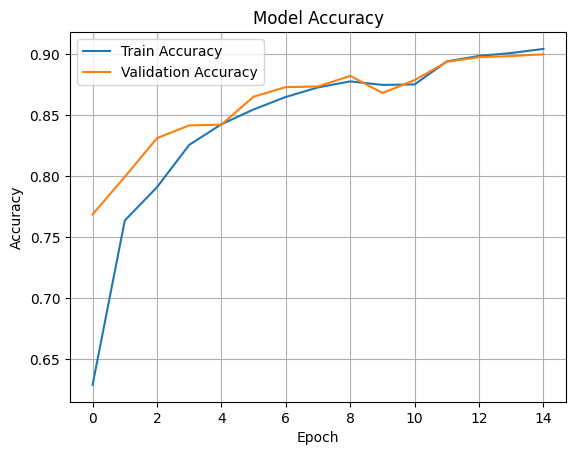

In [22]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.grid()

plt.show()

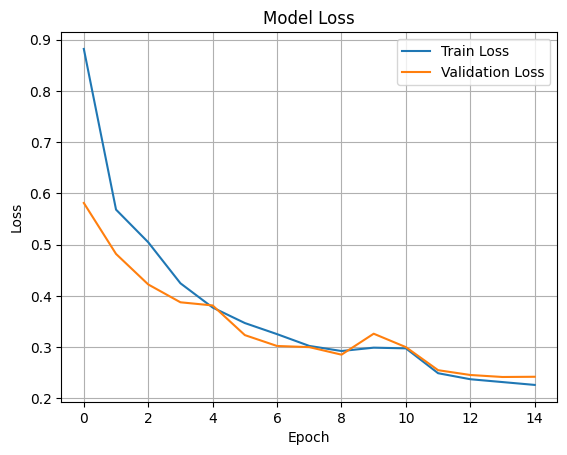

In [23]:
# Loss plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])
plt.grid()

plt.show()

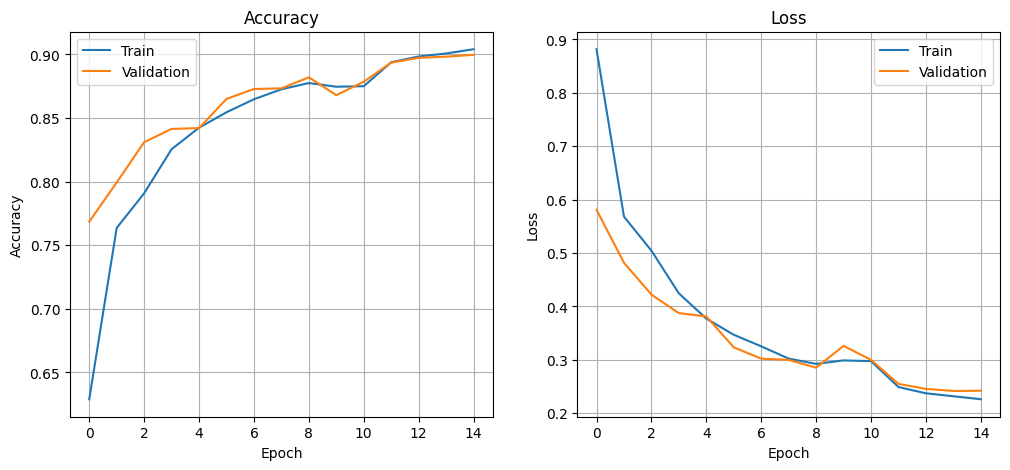

In [24]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid()

plt.show()

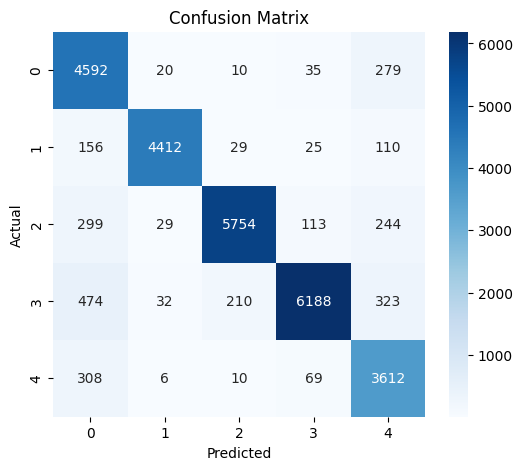

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [26]:
model.save("driver_behavior_model.keras")

In [27]:
import joblib

In [28]:
label_map = {
    1: "Very Rash",
    2: "Rash",
    3: "Balanced",
    4: "Safe",
    5: "Very Safe"
}

joblib.dump(label_map, "label_map.pkl")

['label_map.pkl']

In [29]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [30]:
from google.colab import files

files.download("driver_behavior_model.keras")
files.download("scaler.pkl")
files.download("label_map.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import load_model
import joblib

model = load_model("driver_behavior_model.keras")
scaler = joblib.load("scaler.pkl")
label_map = joblib.load("label_map.pkl")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
